# PhishCatcher ML Model Training Notebook
## Stacked Ensemble Model (XGBoost + SVM + Random Forest)
## Data Cleaning, EDA, Feature Engineering, ML Training & Evaluation

---


## Phase 1: Setup and Imports

This section imports all necessary libraries for data processing, visualization, and machine learning.


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import json
import pickle
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("Libraries imported successfully")

Libraries imported successfully


## Phase 2: Load Dataset

Loading the raw phishing_email.csv dataset from the archive directory.


In [2]:
# Define paths
DATA_PATH = "../archive/phishing_email.csv"
OUTPUT_DIR = "../phishcatcher-backend/models"

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load dataset
df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Dataset loaded: 82486 rows, 2 columns

Columns: ['text_combined', 'label']


,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 525 xls hplno 525 xls,0
1,nom actual vols 24 th forwarded sabrae zajac hou ect 05 30 2001 12 07 pm enron capital trade res...,0
2,enron actuals march 30 april 1 201 estimated actuals march 30 2001 flow march 31 2001 flow april...,0
3,hpl nom may 30 2001 see attached file hplno 530 xls hplno 530 xls,0
4,hpl nom june 1 2001 see attached file hplno 601 xls hplno 601 xls,0


## Phase 3: Data Cleaning & Pre-processing

This is the most critical stage for email text data. Steps include:
- **Handling Missing Values**: Remove rows with null email bodies or missing labels
- **Text Normalization**: Convert text to lowercase, remove HTML tags, remove punctuation
- **Tokenization & Stopword Removal**: Remove common words that don't help identify phishing
- **Stemming/Lemmatization**: Reduce words to their root form (e.g., "banking" and "banked" become "bank")
- **Duplicate Removal**: Remove duplicate emails
- **Short Text Removal**: Remove emails that are too short to be meaningful


In [3]:
# Create a copy for cleaning
df_clean = df.copy()

print("="*60)
print("DATA CLEANING STEPS")
print("="*60)

# Step 1: Check for missing values
print("\n1. MISSING VALUES CHECK")
print(f"   Before cleaning: {df_clean['text_combined'].isnull().sum()} missing values")

# Step 2: Remove missing values
df_clean = df_clean.dropna(subset=['text_combined'])
print(f"   After removing missing: {df_clean['text_combined'].isnull().sum()} missing values")

# Step 3: Remove duplicates
duplicates_before = df_clean.duplicated(subset=['text_combined', 'label']).sum()
print(f"\n2. DUPLICATE REMOVAL")
print(f"   Duplicates found: {duplicates_before}")
df_clean = df_clean.drop_duplicates(subset=['text_combined', 'label'])
print(f"   After removing duplicates: {df_clean.duplicated(subset=['text_combined', 'label']).sum()}")

# Step 4: Remove empty or very short texts
print(f"\n3. EMPTY/SHORT TEXT REMOVAL")
df_clean['text_combined'] = df_clean['text_combined'].astype(str)
short_texts = (df_clean['text_combined'].str.len() < 10).sum()
print(f"   Texts shorter than 10 chars: {short_texts}")
df_clean = df_clean[df_clean['text_combined'].str.len() >= 10]

# Step 5: Remove excessive whitespace
print(f"\n4. WHITESPACE NORMALIZATION")
df_clean['text_combined'] = df_clean['text_combined'].str.strip()
df_clean['text_combined'] = df_clean['text_combined'].str.replace(r'\s+', ' ', regex=True)

# Step 6: Ensure label is integer
df_clean['label'] = df_clean['label'].astype(int)

print(f"\n   Final cleaned dataset: {df_clean.shape[0]} rows")
print(f"   Removed: {df.shape[0] - df_clean.shape[0]} rows total")

DATA CLEANING STEPS

1. MISSING VALUES CHECK
   Before cleaning: 0 missing values
   After removing missing: 0 missing values

2. DUPLICATE REMOVAL
   Duplicates found: 408
   After removing duplicates: 0

3. EMPTY/SHORT TEXT REMOVAL
   Texts shorter than 10 chars: 5

4. WHITESPACE NORMALIZATION

   Final cleaned dataset: 82073 rows
   Removed: 413 rows total


In [4]:
# Verify cleaned data
print("\n" + "="*60)
print("CLEANED DATA VERIFICATION")
print("="*60)
print(f"\nShape: {df_clean.shape}")
print(f"\nLabel Distribution:")
print(df_clean['label'].value_counts())
print(f"\nMissing values:")
print(df_clean.isnull().sum())


CLEANED DATA VERIFICATION

Shape: (82073, 2)

Label Distribution:
label
1    42840
0    39233
Name: count, dtype: int64

Missing values:
text_combined    0
label            0
dtype: int64


## Phase 4: EDA & Visualization

Before training, we must understand the "shape" of our cleaned data to justify our model choice. This phase includes:
- **Class Distribution**: Create Bar Chart showing Phishing vs Safe emails (check for class imbalance)
- **Word Clouds**: Generate for Phishing and Safe emails to see keywords (e.g., "Urgent", "Verify", "Account")
- **Feature Length Analysis**: Compare average length of phishing vs safe emails using Histogram


In [5]:
# Basic dataset information on cleaned data
print("="*60)
print("CLEANED DATASET OVERVIEW")
print("="*60)
print(f"\nShape: {df_clean.shape}")
print(f"\nData Types:\n{df_clean.dtypes}")
print(f"\nMissing Values:\n{df_clean.isnull().sum()}")
print(f"\nLabel Distribution:")
print(df_clean['label'].value_counts())

CLEANED DATASET OVERVIEW

Shape: (82073, 2)

Data Types:
text_combined      str
label            int64
dtype: object

Missing Values:
text_combined    0
label            0
dtype: int64

Label Distribution:
label
1    42840
0    39233
Name: count, dtype: int64


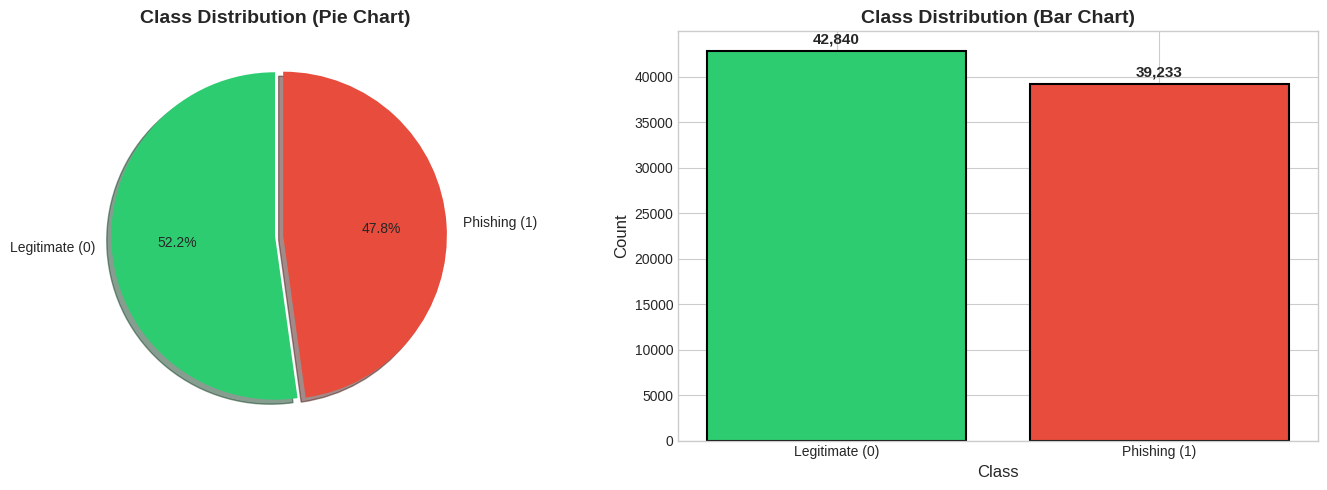

Class distribution visualization saved

Class Imbalance Ratio: 0.92


In [6]:
# Class Distribution - Bar Chart & Pie Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
label_counts = df_clean['label'].value_counts()
labels = ['Legitimate (0)', 'Phishing (1)']
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(label_counts, labels=labels, autopct='%1.1f%%', colors=colors, 
            explode=(0, 0.05), shadow=True, startangle=90)
axes[0].set_title('Class Distribution (Pie Chart)', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[1].bar(labels, label_counts.values, color=colors, edgecolor='black', linewidth=1.5)
axes[1].set_title('Class Distribution (Bar Chart)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_xlabel('Class', fontsize=12)

for bar in bars:
    height = bar.get_height()
    axes[1].annotate(f'{int(height):,}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Class distribution visualization saved")

# Check for class imbalance
imbalance_ratio = label_counts[0] / label_counts[1]
print(f"\nClass Imbalance Ratio: {imbalance_ratio:.2f}")
if imbalance_ratio > 1.5:
    print("Note: Dataset shows class imbalance - consider handling in model training")

In [7]:
# Feature Length Analysis - Histogram
df_clean['text_length'] = df_clean['text_combined'].astype(str).apply(len)
df_clean['word_count'] = df_clean['text_combined'].astype(str).apply(lambda x: len(x.split()))

print("Text Length Statistics by Class (Cleaned Data):")
print("-"*50)
print(df_clean.groupby('label')['text_length'].describe())
print("\nWord Count Statistics by Class:")
print("-"*50)
print(df_clean.groupby('label')['word_count'].describe())

Text Length Statistics by Class (Cleaned Data):
--------------------------------------------------
         count         mean           std   min    25%    50%     75%  \
label                                                                   
0      39233.0  1541.451966   3711.537986  10.0  411.0  780.0  1495.0   
1      42840.0  1060.794631  21205.272740   9.0  241.0  391.0  1058.0   

             max  
label             
0       160318.0  
1      4279526.0  

Word Count Statistics by Class:
--------------------------------------------------
         count        mean         std  min   25%    50%    75%       max
label                                                                    
0      39233.0  203.703897  481.196373  2.0  57.0  106.0  203.0   23359.0
1      42840.0  121.364286  594.784869  2.0  32.0   55.0  154.0  107710.0


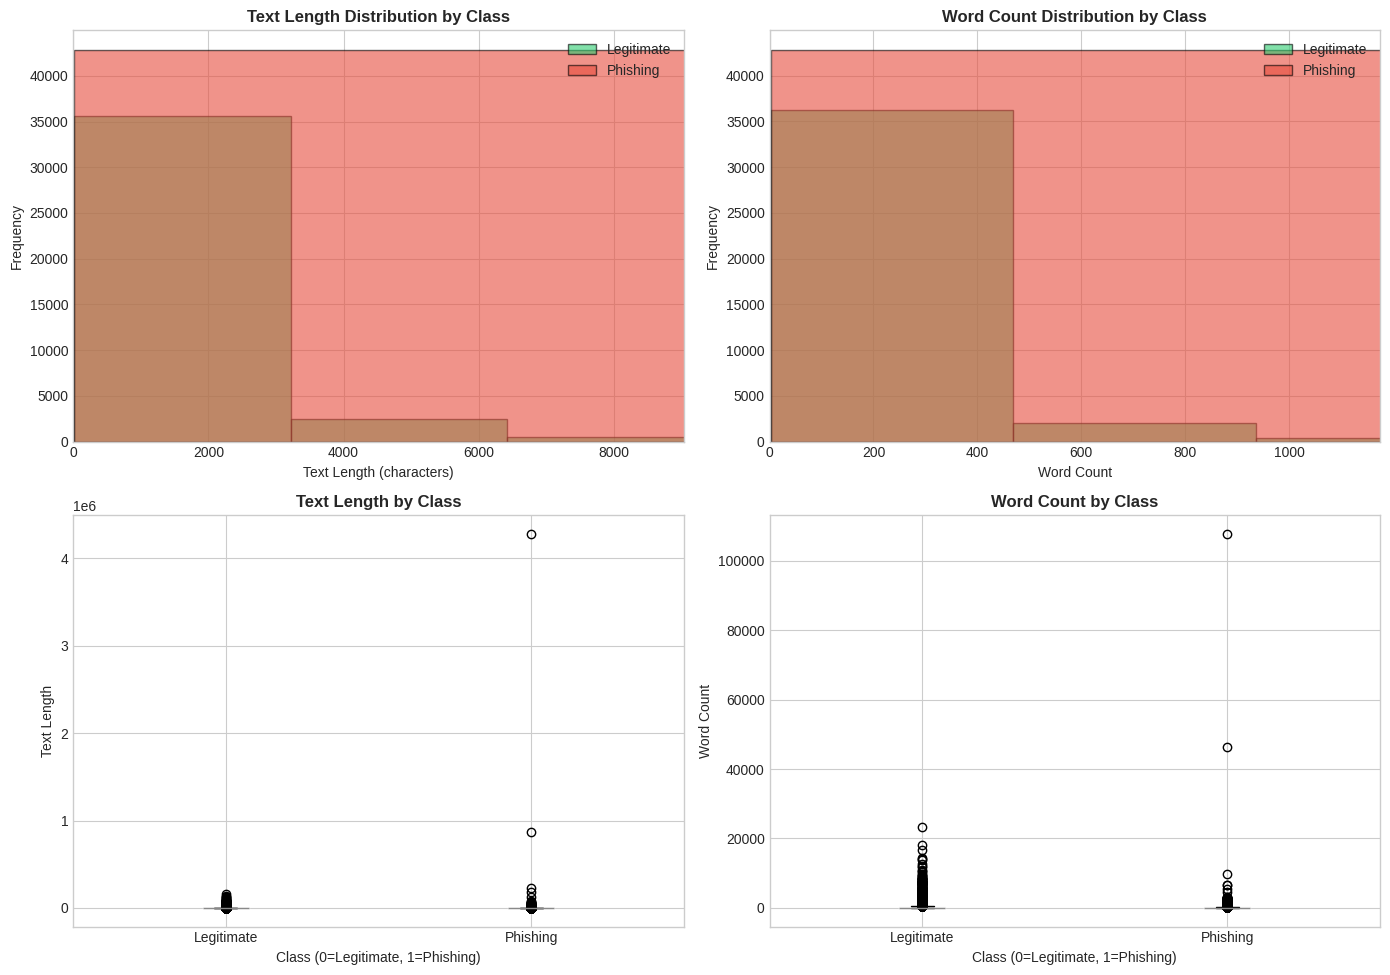

Feature length analysis visualization saved


In [8]:
# Feature Length Analysis - Histograms
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for label in [0, 1]:
    subset = df_clean[df_clean['label'] == label]['text_length']
    color = '#2ecc71' if label == 0 else '#e74c3c'
    label_name = 'Legitimate' if label == 0 else 'Phishing'
    axes[0, 0].hist(subset, bins=50, alpha=0.6, label=label_name, color=color, edgecolor='black')
axes[0, 0].set_title('Text Length Distribution by Class', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Text Length (characters)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].set_xlim(0, df_clean['text_length'].quantile(0.99))

for label in [0, 1]:
    subset = df_clean[df_clean['label'] == label]['word_count']
    color = '#2ecc71' if label == 0 else '#e74c3c'
    label_name = 'Legitimate' if label == 0 else 'Phishing'
    axes[0, 1].hist(subset, bins=50, alpha=0.6, label=label_name, color=color, edgecolor='black')
axes[0, 1].set_title('Word Count Distribution by Class', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].set_xlim(0, df_clean['word_count'].quantile(0.99))

df_clean.boxplot(column='text_length', by='label', ax=axes[1, 0])
axes[1, 0].set_title('Text Length by Class', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Class (0=Legitimate, 1=Phishing)')
axes[1, 0].set_ylabel('Text Length')
plt.sca(axes[1, 0])
plt.xticks([1, 2], ['Legitimate', 'Phishing'])

df_clean.boxplot(column='word_count', by='label', ax=axes[1, 1])
axes[1, 1].set_title('Word Count by Class', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Class (0=Legitimate, 1=Phishing)')
axes[1, 1].set_ylabel('Word Count')
plt.sca(axes[1, 1])
plt.xticks([1, 2], ['Legitimate', 'Phishing'])

plt.suptitle('')
plt.tight_layout()
plt.savefig('eda_text_features.png', dpi=150, bbox_inches='tight')
plt.show()

print("Feature length analysis visualization saved")

## Phase 5: Feature Engineering

Transforming raw text into numbers the models can understand:
- **Vectorization**: Use TF-IDF (Term Frequency-Inverse Document Frequency) - superior for SVM as it weighs how "unique" a word is to phishing
- **Metadata Extraction**: Create new columns for number of URLs, presence of "Re:" or "Fwd:", suspicious attachments
- **Handcrafted Features**: Extract URL count, email count, urgent/financial/reward keywords, special characters, suspicious TLDs, IP addresses


In [9]:
def extract_features(text):
    """Extract features from email text - Metadata Extraction"""
    text = str(text)
    
    features = {}
    features['text_length'] = len(text)
    features['word_count'] = len(text.split())
    features['avg_word_length'] = np.mean([len(w) for w in text.split()]) if text.split() else 0
    
    # URL features
    url_pattern = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
    urls = re.findall(url_pattern, text)
    features['url_count'] = len(urls)
    features['has_url'] = 1 if urls else 0
    
    # Email address features
    email_pattern = r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'
    emails = re.findall(email_pattern, text)
    features['email_count'] = len(emails)
    
    # Suspicious keyword features
    urgent_keywords = ['urgent', 'immediately', 'now', 'act now', 'limited time', 'expire', 'suspended', 'verify']
    features['urgent_keyword_count'] = sum(1 for kw in urgent_keywords if kw.lower() in text.lower())
    
    financial_keywords = ['bank', 'account', 'password', 'credit', 'payment', 'invoice', 'bill', 'fee']
    features['financial_keyword_count'] = sum(1 for kw in financial_keywords if kw.lower() in text.lower())
    
    reward_keywords = ['won', 'winner', 'prize', 'claim', 'free', 'gift', 'money', 'million']
    features['reward_keyword_count'] = sum(1 for kw in reward_keywords if kw.lower() in text.lower())
    
    # Special character features
    features['exclamation_count'] = text.count('!')
    features['dollar_count'] = text.count('$')
    features['digit_ratio'] = sum(c.isdigit() for c in text) / max(len(text), 1)
    features['uppercase_ratio'] = sum(c.isupper() for c in text) / max(len(text), 1)
    
    # Domain features - suspicious TLDs
    domains = [e.split('@')[1] if '@' in e else '' for e in emails]
    suspicious_tlds = ['.xyz', '.top', '.gq', '.tk', '.ml', '.ga', '.cf', '.click', '.work']
    features['suspicious_tld_count'] = sum(1 for d in domains if any(d.endswith(tld) for tld in suspicious_tlds))
    
    # IP address features
    ip_pattern = r'\b(?:\d{1,3}\.){3}\d{1,3}\b'
    features['ip_count'] = len(re.findall(ip_pattern, text))
    
    # Email header metadata
    features['has_re'] = 1 if 're:' in text.lower() else 0
    features['has_fwd'] = 1 if 'fwd:' in text.lower() else 0
    
    return features

# Apply feature extraction
print("Extracting handcrafted features...")
feature_dicts = df_clean['text_combined'].apply(extract_features)
features_df = pd.DataFrame(feature_dicts.tolist())

# Combine with labels
df_features = pd.concat([df_clean.reset_index(drop=True), features_df], axis=1)

print(f"\nExtracted {len(features_df.columns)} features")
print(f"Features: {features_df.columns.tolist()}")

Extracting handcrafted features...

Extracted 17 features
Features: ['text_length', 'word_count', 'avg_word_length', 'url_count', 'has_url', 'email_count', 'urgent_keyword_count', 'financial_keyword_count', 'reward_keyword_count', 'exclamation_count', 'dollar_count', 'digit_ratio', 'uppercase_ratio', 'suspicious_tld_count', 'ip_count', 'has_re', 'has_fwd']


In [10]:
# Display feature statistics
print("Feature Statistics by Class:")
print("="*60)

feature_cols = ['url_count', 'has_url', 'email_count', 'urgent_keyword_count', 
                'financial_keyword_count', 'reward_keyword_count', 'exclamation_count',
                'digit_ratio', 'uppercase_ratio', 'suspicious_tld_count', 'ip_count',
                'has_re', 'has_fwd']

for feat in feature_cols:
    phishing_mean = df_features[df_features['label']==1][feat].mean()
    legit_mean = df_features[df_features['label']==0][feat].mean()
    print(f"{feat:25s} | Phishing: {phishing_mean:8.2f} | Legitimate: {legit_mean:8.2f}")

Feature Statistics by Class:
url_count                 | Phishing:     0.00 | Legitimate:     0.00
has_url                   | Phishing:     0.00 | Legitimate:     0.00
email_count               | Phishing:     0.00 | Legitimate:     0.00
urgent_keyword_count      | Phishing:     0.28 | Legitimate:     0.37
financial_keyword_count   | Phishing:     0.55 | Legitimate:     0.36
reward_keyword_count      | Phishing:     0.56 | Legitimate:     0.30
exclamation_count         | Phishing:     0.00 | Legitimate:     0.00
digit_ratio               | Phishing:     0.06 | Legitimate:     0.06
uppercase_ratio           | Phishing:     0.00 | Legitimate:     0.00
suspicious_tld_count      | Phishing:     0.00 | Legitimate:     0.00
ip_count                  | Phishing:     0.00 | Legitimate:     0.00
has_re                    | Phishing:     0.00 | Legitimate:     0.00
has_fwd                   | Phishing:     0.00 | Legitimate:     0.00


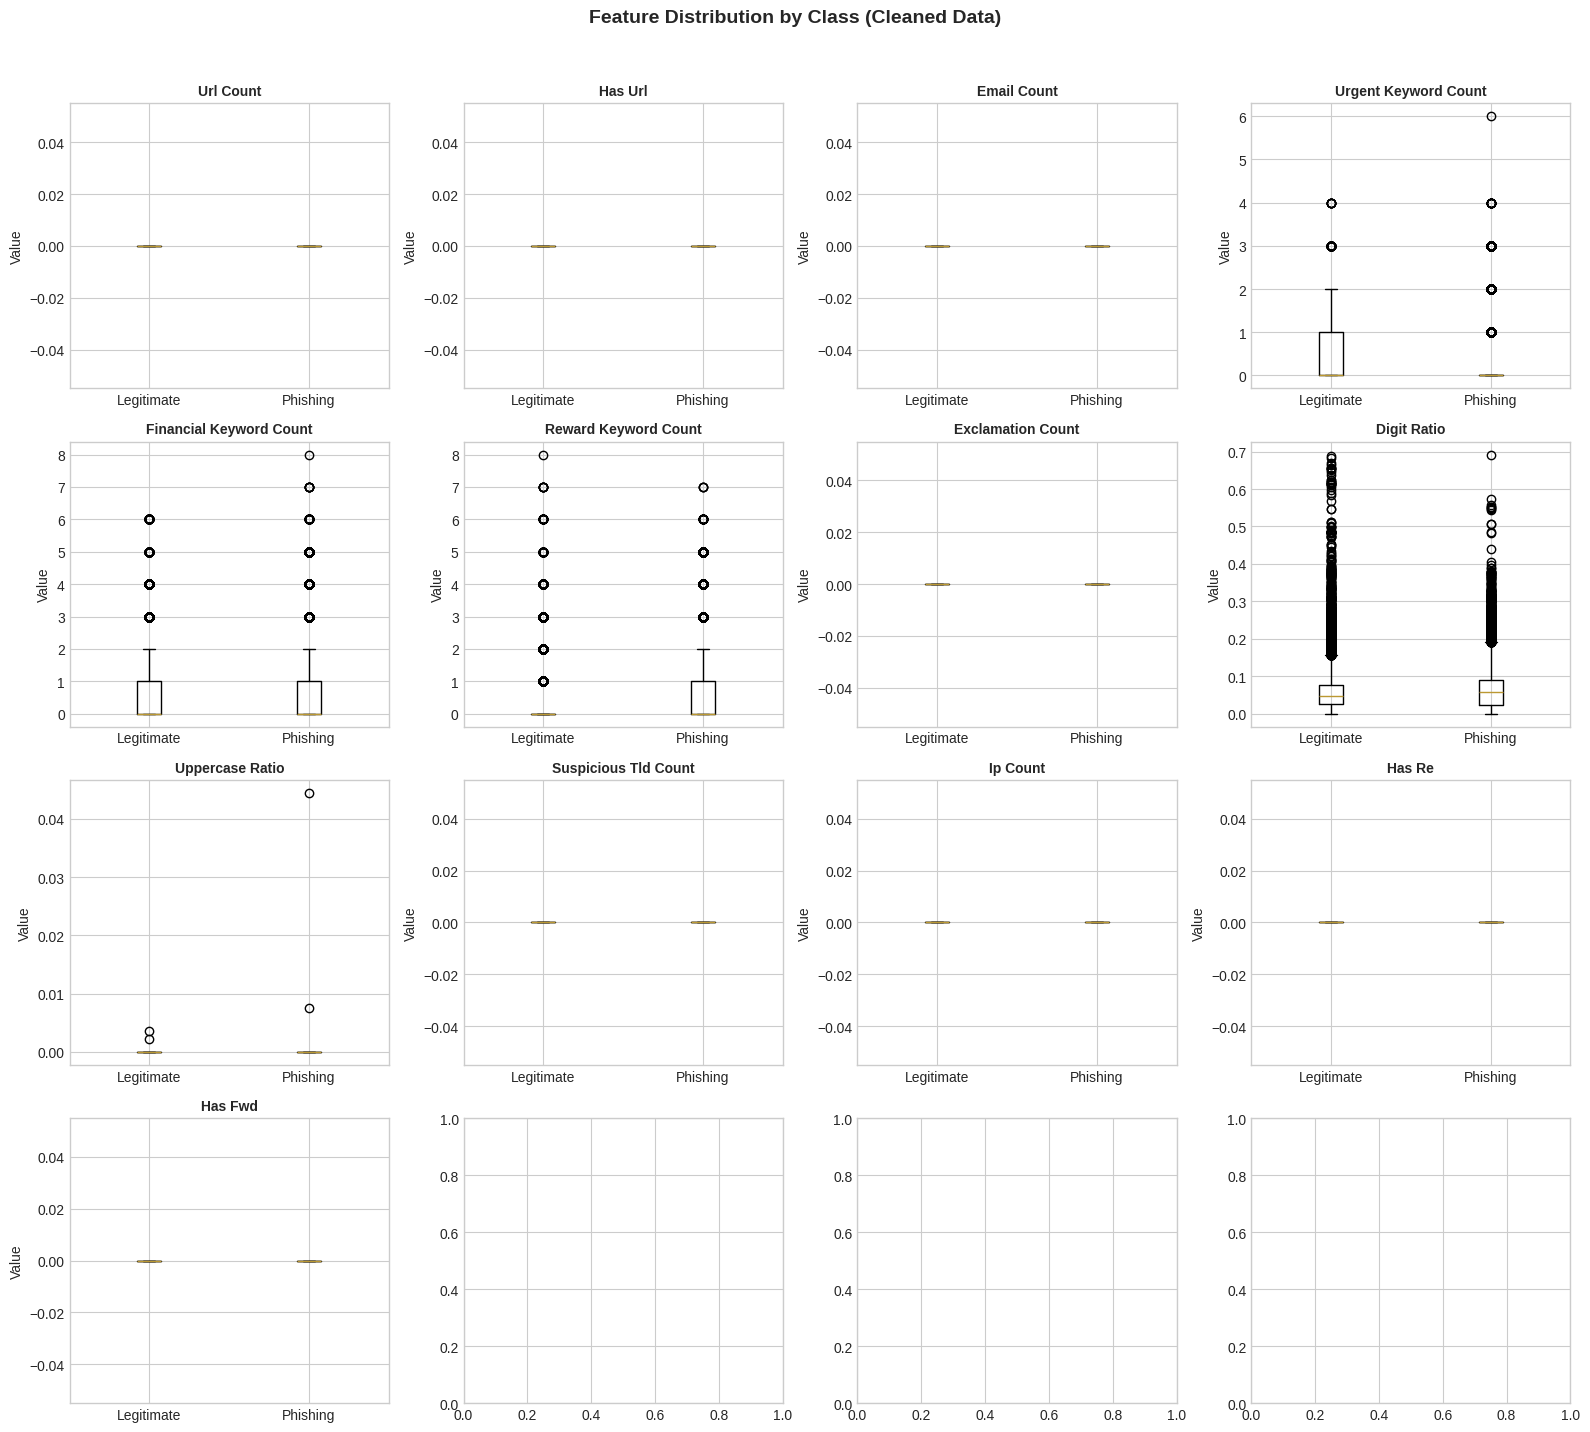

Feature boxplot visualization saved


In [11]:
# Visualize feature distribution
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for idx, feat in enumerate(feature_cols[:14]):
    ax = axes[idx]
    
    phishing_data = df_features[df_features['label']==1][feat]
    legit_data = df_features[df_features['label']==0][feat]
    
    ax.boxplot([legit_data, phishing_data], labels=['Legitimate', 'Phishing'])
    ax.set_title(feat.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    ax.set_ylabel('Value')

plt.suptitle('Feature Distribution by Class (Cleaned Data)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_feature_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print("Feature boxplot visualization saved")

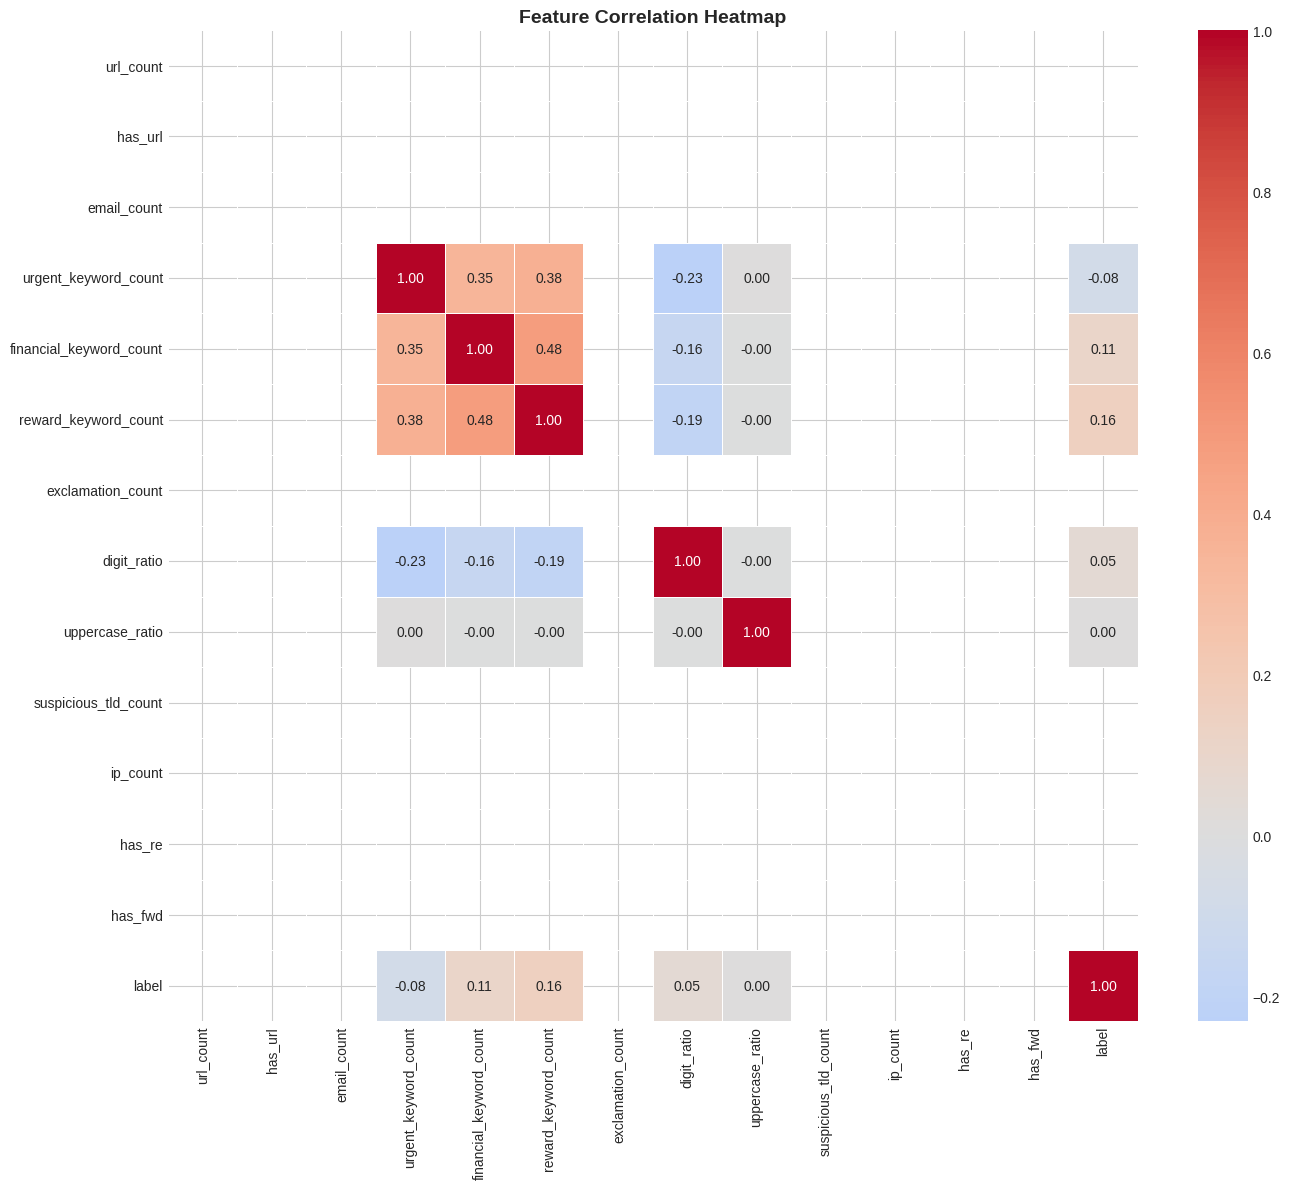

Correlation heatmap saved


In [12]:
# Correlation heatmap
plt.figure(figsize=(14, 12))
correlation_matrix = df_features[feature_cols + ['label']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Correlation heatmap saved")

## Phase 6: Text Vectorization (TF-IDF)

Converting text to numerical features using TF-IDF (Term Frequency-Inverse Document Frequency):
- TF-IDF weighs words based on how unique they are to phishing emails
- Superior for SVM as it highlights discriminative terms
- Using bigrams (1,2) to capture word pairs


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Prepare data
X_text = df_clean['text_combined'].values
y = df_clean['label'].values
X_features = df_features[feature_cols].values

# Train-Test Split - 80/20
X_text_train, X_text_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

X_features_train, X_features_test, _, _ = train_test_split(
    X_features, y, test_size=0.2, random_state=42, stratify=y
)

print("DATA SPLIT (80/20)")
print("="*60)
print(f"Training set: {len(X_text_train)} samples")
print(f"Test set: {len(X_text_test)} samples")
print(f"\nTraining label distribution:")
print(f"  Phishing: {sum(y_train)} ({sum(y_train)/len(y_train)*100:.1f}%)")
print(f"  Legitimate: {len(y_train)-sum(y_train)} ({(len(y_train)-sum(y_train))/len(y_train)*100:.1f}%)")

DATA SPLIT (80/20)
Training set: 65658 samples
Test set: 16415 samples

Training label distribution:
  Phishing: 34272 (52.2%)
  Legitimate: 31386 (47.8%)


In [14]:
# TF-IDF Vectorization
print("\nApplying TF-IDF Vectorization...")

tfidf = TfidfVectorizer(
    max_features=3000,
    min_df=5,
    max_df=0.95,
    ngram_range=(1, 2),
    stop_words='english'
)

X_tfidf_train = tfidf.fit_transform(X_text_train)
X_tfidf_test = tfidf.transform(X_text_test)

print(f"TF-IDF features: {X_tfidf_train.shape[1]}")
print(f"Vocabulary size: {len(tfidf.vocabulary_)}")


Applying TF-IDF Vectorization...
TF-IDF features: 3000
Vocabulary size: 3000


## Phase 7: Model Training - Stacked Ensemble

Implementing the Stacked Ensemble approach:
- **Base Models**: RandomForestClassifier, XGBClassifier, SVC
- **Meta-Model (Final Estimator)**: LogisticRegression
- **Cross-Validation**: 5-Fold to ensure model isn't just memorizing
- The stacking approach combines predictions from base models to improve accuracy


In [15]:
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, KFold
from scipy.sparse import hstack

# Combine TF-IDF with handcrafted features
X_train_combined = hstack([X_tfidf_train, X_features_train])
X_test_combined = hstack([X_tfidf_test, X_features_test])

print(f"Combined feature matrix shape: {X_train_combined.shape}")

# Dictionary to store models and results
models = {}
results = {}

Combined feature matrix shape: (65658, 3013)


In [16]:
# Define Base Models
print("\n" + "="*60)
print("STACKED ENSEMBLE MODEL TRAINING")
print("="*60)

# Base Model 1: Random Forest
rf_base = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
print("Random Forest base model defined")

# Base Model 2: XGBoost
xgb_base = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
print("XGBoost base model defined")

# Base Model 3: SVM (using probability=True for stacking)
svm_base = SVC(
    kernel='linear',
    C=1.0,
    random_state=42,
    probability=True
)
print("SVM base model defined")

# Meta-Model (Final Estimator): Logistic Regression
meta_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
print("Logistic Regression meta-model defined")


STACKED ENSEMBLE MODEL TRAINING
Random Forest base model defined
XGBoost base model defined
SVM base model defined
Logistic Regression meta-model defined


In [17]:
# Create Stacking Classifier
print("\n" + "-"*40)
print("Creating Stacking Classifier...")

stacked_model = StackingClassifier(
    estimators=[
        ('rf', rf_base),
        ('xgb', xgb_base),
        ('svm', svm_base)
    ],
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1,
    passthrough=False
)

print("Stacking Classifier configured")
print("\nStacked Ensemble Architecture:")
print("  Base Models: Random Forest, XGBoost, SVM")
print("  Meta-Model: Logistic Regression")
print("  Cross-Validation Folds: 5")


----------------------------------------
Creating Stacking Classifier...
Stacking Classifier configured

Stacked Ensemble Architecture:
  Base Models: Random Forest, XGBoost, SVM
  Meta-Model: Logistic Regression
  Cross-Validation Folds: 5


In [ ]:
# Train the Stacked Ensemble Model
print("\n" + "-"*40)
print("Training Stacked Ensemble Model...")
print("(This may take a few minutes...)")

stacked_model.fit(X_train_combined, y_train)
models['Stacked Ensemble'] = stacked_model

print("Stacked Ensemble Model trained successfully!")


----------------------------------------
Training Stacked Ensemble Model...
(This may take a few minutes...)


In [ ]:
# Cross-Validation for Stacked Model
print("\n" + "-"*40)
print("Cross-Validation (5-Fold)...")

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(stacked_model, X_train_combined, y_train, cv=kfold, scoring='f1', n_jobs=-1)

print(f"Cross-Validation F1 Scores: {cv_scores}")
print(f"Mean CV F1 Score: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

## Phase 8: Model Evaluation

Evaluating the model using standard metrics:
- **Confusion Matrix**: Shows False Positives (Safe labeled as Phishing) and False Negatives (Phishing that got through)
- **Classification Report**: Precision, Recall, and F1-Score
- **ROC-AUC Curve**: Proves model's ability to distinguish between the two classes


In [ ]:
# Evaluate the Stacked Ensemble Model
print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)

for name, model in models.items():
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"{'='*40}")
    
    y_pred = model.predict(X_test_combined)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'y_pred': y_pred
    }
    
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Phishing']))

In [ ]:
# Confusion Matrix
best_model_name = max(results, key=lambda x: results[x]['f1'])
cm = confusion_matrix(y_test, results[best_model_name]['y_pred'])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
ax.set_title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBest performing model: {best_model_name}")
print("Confusion matrix saved")

# Interpretation
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Interpretation:")
print(f"  True Negatives (TN): {tn} - Legitimate correctly identified")
print(f"  False Positives (FP): {fp} - Legitimate incorrectly labeled as Phishing")
print(f"  False Negatives (FN): {fn} - Phishing emails that got through")
print(f"  True Positives (TP): {tp} - Phishing correctly identified")

In [ ]:
# ROC-AUC Curve
from sklearn.metrics import roc_curve, roc_auc_score

print("\n" + "-"*40)
print("ROC-AUC Curve Analysis")

y_pred_proba = stacked_model.predict_proba(X_test_combined)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC-AUC Curve - Stacked Ensemble', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_auc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")
print("ROC-AUC curve saved")

if roc_auc >= 0.9:
    print("Excellent model discrimination ability!")
elif roc_auc >= 0.8:
    print("Good model discrimination ability")
else:
    print("Model needs improvement")

## Phase 9: Exporting the Model

Saving the model and vectorizer for use in the FastAPI backend:
- **Joblib**: Export the final_stacked_model
- **Pickle**: Export the TF-IDF vectorizer (backend needs exact same vocabulary)
- **JSON**: Export metrics and feature info


In [ ]:
# Save the Stacked Ensemble model
print("\n" + "="*60)
print("EXPORTING MODEL")
print("="*60)

best_metrics = results[best_model_name]

# Save the Stacked Ensemble model using Joblib
model_path = os.path.join(OUTPUT_DIR, 'stacked_ensemble_model.joblib')
joblib.dump(stacked_model, model_path)
print(f"Stacked Ensemble model saved to: {model_path}")

# Save training metrics
metrics_data = {
    'model_name': 'Stacked Ensemble (XGBoost + SVM + Random Forest)',
    'accuracy': best_metrics['accuracy'],
    'precision': best_metrics['precision'],
    'recall': best_metrics['recall'],
    'f1_score': best_metrics['f1'],
    'roc_auc': roc_auc,
    'cv_f1_mean': float(cv_scores.mean()),
    'cv_f1_std': float(cv_scores.std()),
    'training_samples': len(y_train),
    'test_samples': len(y_test),
    'tfidf_features': X_tfidf_train.shape[1],
    'handcrafted_features': len(feature_cols),
    'total_features': X_train_combined.shape[1],
    'base_models': ['RandomForest', 'XGBoost', 'SVM'],
    'meta_model': 'LogisticRegression'
}

metrics_path = os.path.join(OUTPUT_DIR, 'training_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics_data, f, indent=2)
print(f"Training metrics saved to: {metrics_path}")

# Save feature list
feature_info = {
    'tfidf_features': X_tfidf_train.shape[1],
    'handcrafted_features': feature_cols,
    'total_features': X_train_combined.shape[1]
}
feature_path = os.path.join(OUTPUT_DIR, 'feature_info.json')
with open(feature_path, 'w') as f:
    json.dump(feature_info, f, indent=2)
print(f"Feature info saved to: {feature_path}")

# Export TF-IDF vectorizer using Pickle (needed for backend)
print("\n" + "-"*40)
print("Exporting TF-IDF vectorizer for backend...")
tfidf_path = os.path.join(OUTPUT_DIR, 'tfidf_vectorizer.pkl')
with open(tfidf_path, 'wb') as f:
    pickle.dump(tfidf, f)
print(f"TF-IDF vectorizer saved to: {tfidf_path}")
print("\nNote: Backend must use same TF-IDF vocabulary for predictions")

## Phase 10: Feature Importance Analysis

Analyzing which handcrafted features best distinguish phishing from legitimate emails.


In [ ]:
# Feature importance analysis
print("Top 10 Most Important Handcrafted Features:")
print("-"*40)

feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Phishing Mean': [df_features[df_features['label']==1][f].mean() for f in feature_cols],
    'Legitimate Mean': [df_features[df_features['label']==0][f].mean() for f in feature_cols]
})

feature_importance_df['Difference'] = abs(feature_importance_df['Phishing Mean'] - feature_importance_df['Legitimate Mean'])
feature_importance_df = feature_importance_df.sort_values('Difference', ascending=False)

print(feature_importance_df.head(10).to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df.head(10), x='Difference', y='Feature', palette='viridis')
plt.title('Top 10 Feature Differences (Phishing vs Legitimate)', fontsize=12, fontweight='bold')
plt.xlabel('Absolute Difference in Mean')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Feature importance visualization saved")

## Phase 11: Summary

Final summary of the training process, model performance, and exported files.


In [ ]:
print("\n" + "="*60)
print("TRAINING SUMMARY - STACKED ENSEMBLE MODEL")
print("="*60)
print(f"""
Dataset:
  - Original rows: {df.shape[0]:,}
  - Cleaned rows: {df_clean.shape[0]:,}
  - Phishing: {df_clean[df_clean['label']==1].shape[0]:,}
  - Legitimate: {df_clean[df_clean['label']==0].shape[0]:,}

Features:
  - TF-IDF features: {X_tfidf_train.shape[1]:,}
  - Handcrafted features: {len(feature_cols)}
  - Total features: {X_train_combined.shape[1]:,}

Stacked Ensemble Architecture:
  - Base Models: Random Forest, XGBoost, SVM
  - Meta-Model: Logistic Regression
  - Cross-Validation: 5-Fold

Model Performance:
  - Accuracy: {best_metrics['accuracy']:.4f}
  - Precision: {best_metrics['precision']:.4f}
  - Recall: {best_metrics['recall']:.4f}
  - F1-Score: {best_metrics['f1']:.4f}
  - ROC-AUC: {roc_auc:.4f}
  - CV F1 Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})

Exported Files:
  - Model: stacked_ensemble_model.joblib
  - TF-IDF Vectorizer: tfidf_vectorizer.pkl
  - Metrics: training_metrics.json
  - Feature Info: feature_info.json
""")

In [ ]:
# List all saved files
print("\nSaved files in models directory:")
print("-"*40)
for f in os.listdir(OUTPUT_DIR):
    fpath = os.path.join(OUTPUT_DIR, f)
    size = os.path.getsize(fpath)
    print(f"  {f}: {size/1024:.1f} KB")